In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression

In [2]:
ahs2015 = pd.read_csv('../csv/ahs2015n.csv')
ahs2017 = pd.read_csv('../csv/ahs2017n.csv')
ahs2019 = pd.read_csv('../csv/ahs2019n.csv')
ahs2021 = pd.read_csv('../csv/ahs2021n.csv')
ahs2023 = pd.read_csv('../csv/ahs2023n.csv')

ahs_fields = ['CONTROL', 'WEIGHT', 'DIVISION', 'OMB13CBSA', 'BLD', 'YRBUILT', 'TENURE', 'VACANCY', 'GARAGE', 'LOTSIZE',
        'BEDROOMS', 'BATHROOMS', 'DINING', 'KITCHENS', 'LAUNDY', 'FINROOMS', 'UFINROOMS', 'TOTROOMS', 'STORIES',
        'UNITFLOORS', 'UNITSIZE', 'HSHLDTYPE', 'NUMADULTS', 'NUMOLDKIDS', 'NUMYNGKIDS', 'HHAGE', 'HHCITSHP', 'HHMOVE',
        'HHRACE', 'HHSEX', 'HHGRAD', 'HINCP', 'MORTAMT', 'PROTAXAMT', 'INSURAMT', 'HOAAMT', 'LOTAMT', 'RENT', 'MAINTAMT',
        'UTILAMT', 'TOTHCAMT', 'HOWBUY', 'MARKETVAL'
        ]

ahs2015 = ahs2015[ahs_fields]
ahs2017 = ahs2017[ahs_fields]
ahs2019 = ahs2019[ahs_fields]
ahs2021 = ahs2021[ahs_fields]
ahs2023 = ahs2023[ahs_fields]

ahs_years = [('2015', ahs2015), ('2017', ahs2017), ('2019', ahs2019), ('2021', ahs2021), ('2023', ahs2023)]

for (year, df) in ahs_years:
    for field in ahs_fields:
        if str(df.dtypes[field]) == 'str':
            df[field] = df[field].str.strip("'")

In [3]:
print("2015-2023 AHS dataframe shapes:")
print(f"AHS 2015: {ahs2015.shape}")
print(f"AHS 2017: {ahs2017.shape}")
print(f"AHS 2019: {ahs2019.shape}")
print(f"AHS 2021: {ahs2021.shape}")
print(f"AHS 2023: {ahs2023.shape}")

2015-2023 AHS dataframe shapes:
AHS 2015: (69493, 43)
AHS 2017: (66752, 43)
AHS 2019: (63185, 43)
AHS 2021: (64141, 43)
AHS 2023: (55669, 43)


In [4]:
ahs2021.dtypes

CONTROL           str
WEIGHT        float64
DIVISION          str
OMB13CBSA         str
BLD               str
YRBUILT         int64
TENURE            str
VACANCY           str
GARAGE            str
LOTSIZE           str
BEDROOMS        int64
BATHROOMS         str
DINING          int64
KITCHENS        int64
LAUNDY          int64
FINROOMS        int64
UFINROOMS       int64
TOTROOMS        int64
STORIES         int64
UNITFLOORS      int64
UNITSIZE          str
HSHLDTYPE         str
NUMADULTS       int64
NUMOLDKIDS      int64
NUMYNGKIDS      int64
HHAGE           int64
HHCITSHP          str
HHMOVE          int64
HHRACE            str
HHSEX             str
HHGRAD            str
HINCP           int64
MORTAMT         int64
PROTAXAMT       int64
INSURAMT        int64
HOAAMT          int64
LOTAMT          int64
RENT            int64
MAINTAMT        int64
UTILAMT         int64
TOTHCAMT        int64
HOWBUY            str
MARKETVAL       int64
dtype: object

In [5]:
soc2020 = pd.read_csv('../csv/soc20.csv')
soc2021 = pd.read_csv('../csv/soc21.csv')
soc2022 = pd.read_csv('../csv/soc22.csv')
soc2023 = pd.read_csv('../csv/soc23.csv')
soc2024 = pd.read_csv('../csv/soc24.csv')

soc2020['SOC_YEAR'] = '2020'
soc2021['SOC_YEAR'] = '2021'
soc2022['SOC_YEAR'] = '2022'
soc2023['SOC_YEAR'] = '2023'
soc2024['SOC_YEAR'] = '2024'

soc_fields = ['WEIGHT', 'SOC_YEAR', 'CAT', 'CLOS', 'CON', 'DET', 'DIV', 'GAR', 'LNDR', 'STOR', 'AREA', 'BEDR',
              'FULB', 'HAFB', 'SLPR', 'FSLPR', 'SQFS']

soc2020 = soc2020[soc_fields]
soc2021 = soc2021[soc_fields]
soc2022 = soc2022[soc_fields]
soc2023 = soc2023[soc_fields]
soc2024 = soc2024[soc_fields]

soc_all = pd.concat([soc2020, soc2021, soc2022, soc2023, soc2024])

soc_years = [('2020', soc2020), ('2021', soc2021), ('2022', soc2022), ('2023', soc2023), ('2024', soc2024)]

print("2020-2024 SOC dataframe shapes:")
print(f"SOC 2020: {soc2020.shape}")
print(f"SOC 2021: {soc2021.shape}")
print(f"SOC 2022: {soc2022.shape}")
print(f"SOC 2023: {soc2023.shape}")
print(f"SOC 2024: {soc2024.shape}")
print(f"SOC combined: {soc_all.shape}")

2020-2024 SOC dataframe shapes:
SOC 2020: (25526, 17)
SOC 2021: (26518, 17)
SOC 2022: (26581, 17)
SOC 2023: (25885, 17)
SOC 2024: (25721, 17)
SOC combined: (130231, 17)


In [6]:
soc_all.dtypes

WEIGHT      int64
SOC_YEAR      str
CAT         int64
CLOS        int64
CON         int64
DET         int64
DIV         int64
GAR         int64
LNDR        int64
STOR        int64
AREA        int64
BEDR        int64
FULB        int64
HAFB        int64
SLPR        int64
FSLPR       int64
SQFS        int64
dtype: object

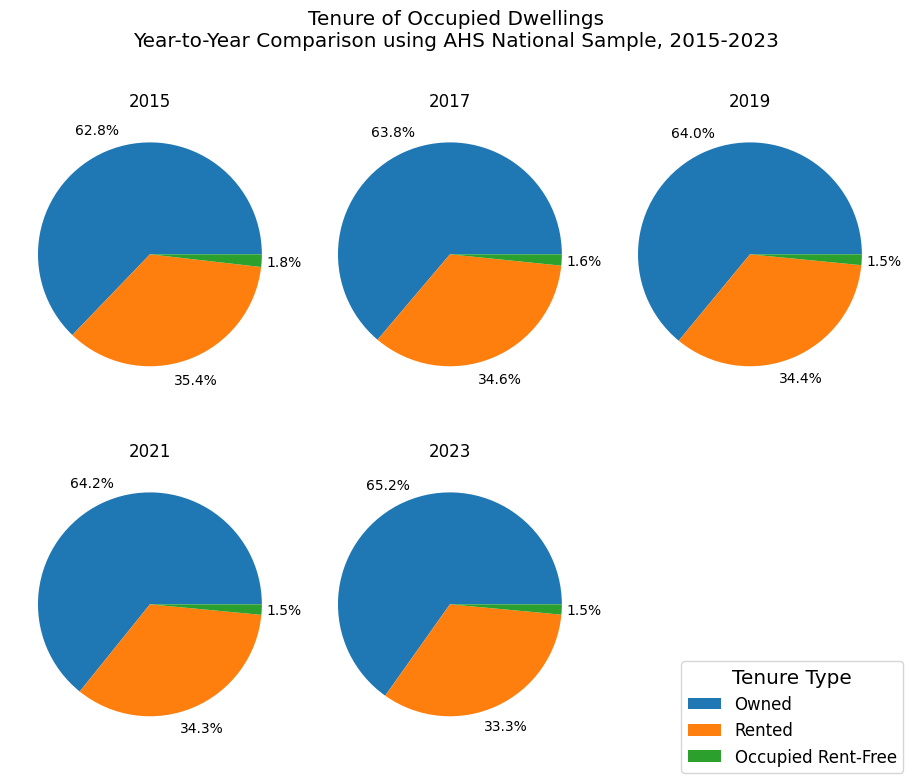

In [7]:
# TENURE DISTRIBUTION, OCCUPIED UNITS (AHS)

fig, axs = plt.subplots(ncols=3, nrows=2, figsize=(9, 7), layout='constrained')
labels = ['Owned', 'Rented', 'Occupied Rent-Free']
fig.suptitle('Tenure of Occupied Dwellings\nYear-to-Year Comparison using AHS National Sample, 2015-2023',
             fontsize='x-large',
             y=1.1
            )

wedges = None

for (i, tp) in enumerate(ahs_years):
    row = i // 3
    col = i % 3
    (year, df) = tp

    df = df[df['TENURE'] != '-6']
    df = df[['WEIGHT', 'TENURE']]
    totals = df.groupby(['TENURE']).sum()
    totals['WEIGHT'] = totals['WEIGHT']/1000

    ax = axs[row, col]
    wedges, _, _ = ax.pie(totals['WEIGHT'], labels=labels, labeldistance=None, pctdistance=1.2, autopct='%1.1f%%')
    ax.set_title(year)

axs[1, 2].set_visible(False)
fig.legend(wedges, labels, loc='lower right', fontsize='large', title_fontsize='x-large', title='Tenure Type')

(2663, 2)
(2257, 2)
(5142, 2)


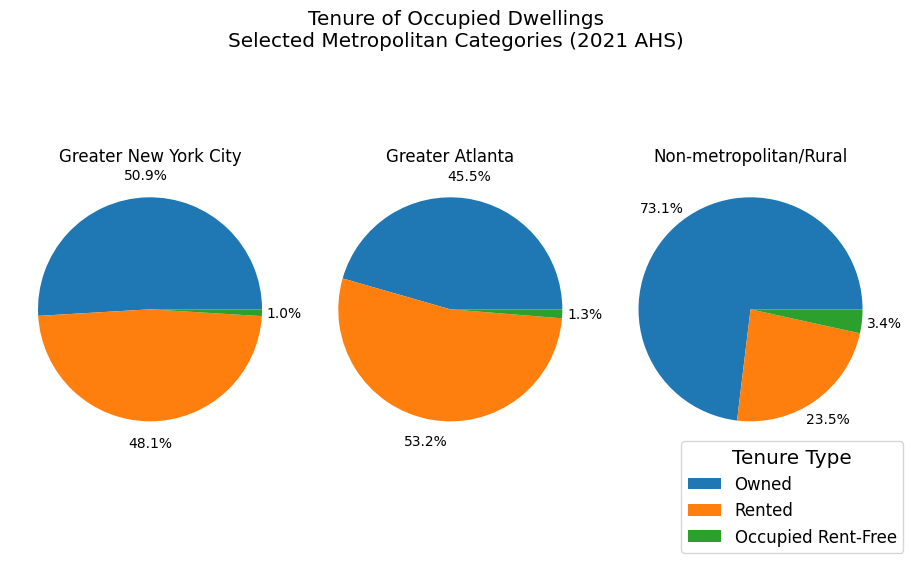

In [8]:
# TENURE DISTRIBUTION, METRO BREAKDOWN (AHS)

fig, axs = plt.subplots(ncols=3, nrows=1, figsize=(9, 5), layout='constrained')
labels = ['Owned', 'Rented', 'Occupied Rent-Free']
fig.suptitle('Tenure of Occupied Dwellings\nSelected Metropolitan Categories (2021 AHS)',
             fontsize='x-large',
             y=1.1
            )

metros = [('Greater New York City', '35620'), ('Greater Atlanta', '31080'), ('Non-metropolitan/Rural', '99999')]

wedges = None

for (i, tp) in enumerate(metros):
    col = i
    (metro, cbsa) = tp

    df = ahs2021[ahs2021['TENURE'] != '-6']
    df = df[df['OMB13CBSA'] == cbsa]
    df = df[['WEIGHT', 'TENURE']]
    print(df.shape)
    totals = df.groupby(['TENURE']).sum()
    totals['WEIGHT'] = totals['WEIGHT']/1000

    ax = axs[col]
    wedges, _, _ = ax.pie(totals['WEIGHT'], labels=labels, labeldistance=None, pctdistance=1.2, autopct='%1.1f%%')
    ax.set_title(metro)

fig.legend(wedges, labels, loc='lower right', fontsize='large', title_fontsize='x-large', title='Tenure Type')

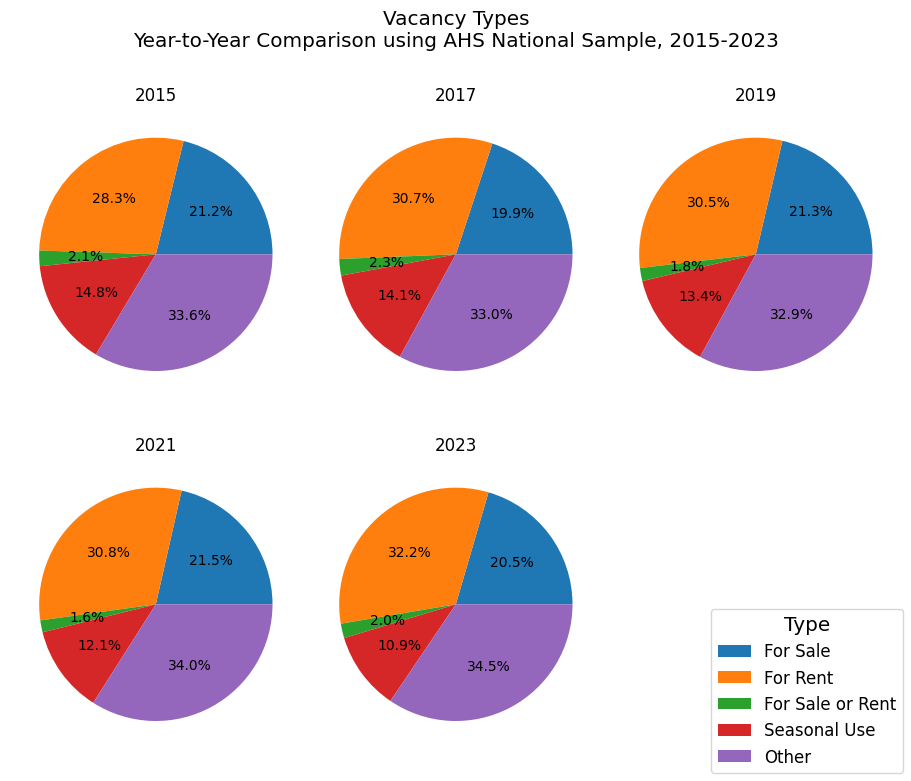

In [9]:
# STATUS DISTRIBUTION, VACANT UNITS (AHS)

def categorize_vac_status(vac):
    if vac == '01' or vac == '04':
        return 'RENTAL'
    elif vac == '03' or vac == '05':
        return 'SALE'
    elif vac == '02':
        return 'RENTSALE'
    elif vac == '07':
        return 'OTHER'
    return 'SEASONAL'

fig, axs = plt.subplots(ncols=3, nrows=2, figsize=(9, 7), layout='constrained')
labels = ['For Sale', 'For Rent', 'For Sale or Rent', 'Seasonal Use', 'Other']
fig.suptitle('Vacancy Types\nYear-to-Year Comparison using AHS National Sample, 2015-2023',
             fontsize='x-large',
             y=1.1
            )

wedges = None

for (i, tp) in enumerate(ahs_years):
    row = i // 3
    col = i % 3
    (year, df) = tp

    df = df[df['VACANCY'] != '-6']
    df = df[['WEIGHT', 'VACANCY']]
    df['VAC2'] = df['VACANCY'].apply(categorize_vac_status)
    df = df[['WEIGHT', 'VAC2']]
    totals = df.groupby(['VAC2']).sum()
    totals['WEIGHT'] = totals['WEIGHT'] / 1000
    totals.reindex(['SALE', 'RENTAL', 'RENTSALE', 'SEASONAL', 'OTHER'])

    ax = axs[row, col]
    wedges, _, _ = ax.pie(totals['WEIGHT'], labels=labels, labeldistance=None, autopct='%1.1f%%')
    ax.set_title(year)

axs[1, 2].set_visible(False)
fig.legend(wedges, labels, loc='lower right', fontsize='large', title_fontsize='x-large', title='Type')

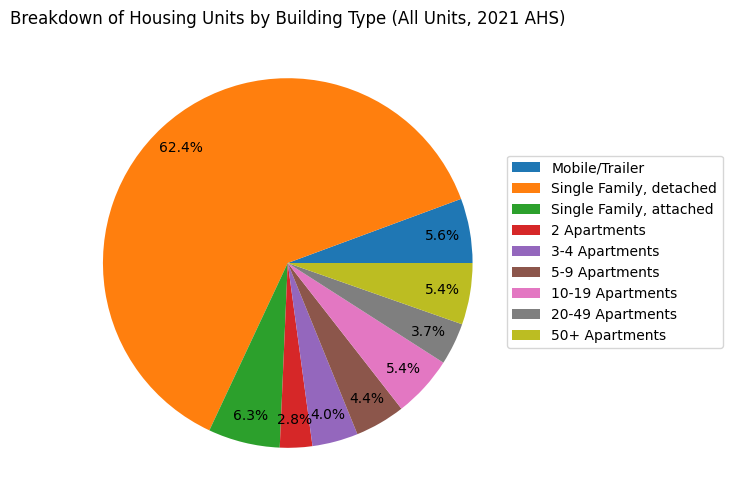

In [10]:
# Structure Type Breakdown, All units, 2021 data

df = ahs2021[['WEIGHT', 'BLD']]
df = df[df['BLD'] != '10']
totals = df.groupby(['BLD']).sum()
totals['WEIGHT'] = totals['WEIGHT'] / 1000
labels = ['Mobile/Trailer', 'Single Family, detached', 'Single Family, attached', '2 Apartments', '3-4 Apartments',
         '5-9 Apartments', '10-19 Apartments', '20-49 Apartments', '50+ Apartments']

fig, ax = plt.subplots(figsize=(9, 6))
ax.set_title('Breakdown of Housing Units by Building Type (All Units, 2021 AHS)')
wedges, _, _ = ax.pie(totals['WEIGHT'], labels=labels, labeldistance=None, autopct='%1.1f%%', pctdistance=0.85)
fig.legend(wedges, labels, loc='center right')


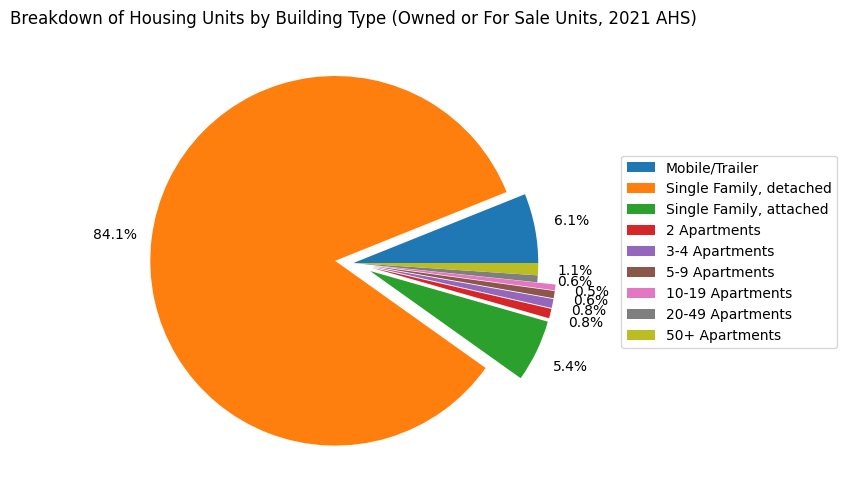

In [11]:
# Structure Type Breakdown, Owned only, 2021 data

df = ahs2021[['WEIGHT', 'BLD', 'TENURE', 'VACANCY']]
df = df[(df['TENURE'] == '1') | (df['VACANCY'] == '03') | (df['VACANCY'] == '05')]
df = df[df['BLD'] != '10']
df = df[['WEIGHT', 'BLD']]
totals = df.groupby(['BLD']).sum()
totals['WEIGHT'] = totals['WEIGHT'] / 1000
labels = ['Mobile/Trailer', 'Single Family, detached', 'Single Family, attached', '2 Apartments', '3-4 Apartments',
         '5-9 Apartments', '10-19 Apartments', '20-49 Apartments', '50+ Apartments']

fig, ax = plt.subplots(figsize=(10, 6))
ax.set_title('Breakdown of Housing Units by Building Type (Owned or For Sale Units, 2021 AHS)')
wedges, _, _= ax.pie(totals['WEIGHT'], labels=labels, labeldistance=None, autopct='%1.1f%%', pctdistance=1.2,
                     explode=(0, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0, 0))
fig.legend(wedges, labels, loc='center right')


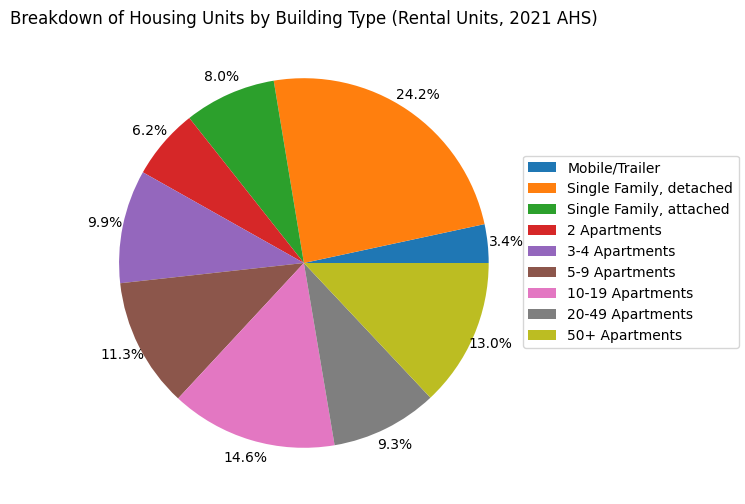

In [12]:
# Structure Type Breakdown, Rented only, 2021 data

df = ahs2021[['WEIGHT', 'BLD', 'TENURE', 'VACANCY']]
df = df[(df['TENURE'] == '2') | (df['VACANCY'] == '01') | (df['VACANCY'] == '04')]
df = df[df['BLD'] != '10']
df = df[['WEIGHT', 'BLD']]
totals = df.groupby(['BLD']).sum()
totals['WEIGHT'] = totals['WEIGHT'] / 1000
labels = ['Mobile/Trailer', 'Single Family, detached', 'Single Family, attached', '2 Apartments', '3-4 Apartments',
         '5-9 Apartments', '10-19 Apartments', '20-49 Apartments', '50+ Apartments']

fig, ax = plt.subplots(figsize=(9, 6))
ax.set_title('Breakdown of Housing Units by Building Type (Rental Units, 2021 AHS)')
wedges, _, _= ax.pie(totals['WEIGHT'], labels=labels, labeldistance=None, autopct='%1.1f%%', pctdistance=1.1)
fig.legend(wedges, labels, loc='center right')


In [13]:
# Function for pre-calculating boxplot values using weights

def get_bxpstats(fieldname, cat, log=False):
    df, label = cat
    sum_weight = df['WEIGHT'].sum()
    q1_wt = sum_weight / 4
    q2_wt = sum_weight / 2
    q3_wt = 3 * sum_weight / 4

    df = df.sort_values(by=fieldname, inplace=False)
    if log:
        df[fieldname] = np.log10(df[fieldname])
    df['CW'] = df['WEIGHT'].cumsum()
    df[f'{fieldname}_SCALED'] = df[fieldname] * (df['WEIGHT'] / sum_weight)

    q1 = df[df['CW'] >= q1_wt].iloc[0][fieldname]
    q2 = df[df['CW'] >= q2_wt].iloc[0][fieldname]
    q3 = df[df['CW'] >= q3_wt].iloc[0][fieldname]

    iqr = q3 - q1
    whis_min = q1 - (1.5 * iqr)
    whis_max = q3 + (1.5 * iqr)

    weighted_mean = df[f'{fieldname}_SCALED'].sum()

    whis_low = df[df[fieldname] >= whis_min].iloc[0][fieldname]
    whis_high = df[df[fieldname] <= whis_max].iloc[-1][fieldname]

    fliers = df[(df[fieldname] > whis_high) | (df[fieldname] < whis_low)][fieldname]

    return {'med': q2, 'q1': q1, 'q3': q3, 'whislo': whis_low,
            'whishi': whis_high, 'fliers': fliers, 'label': label, 'mean': weighted_mean}

In [14]:
# Housing Cost vs. Household Income Analysis, 2021 data

df = ahs2021[['WEIGHT', 'TENURE', 'HINCP', 'TOTHCAMT', 'OMB13CBSA']]
df = df[df['TOTHCAMT'] != -6]
df = df[df['HINCP'] != -6]
df = df[df['TENURE'] != '-6']
df = df[df['TENURE'] != '3']

df_owned = df[df['TENURE'] == '1']
df_rented = df[df['TENURE'] == '2']

bp_all_no_log = median_all = get_bxpstats('TOTHCAMT', (df, 'All'))
bp_owned_no_log = get_bxpstats('TOTHCAMT', (df_owned, 'Owned'))
bp_rented_no_log = get_bxpstats('TOTHCAMT', (df_rented, 'Rented'))

median_all = bp_all_no_log['med']
median_owned = bp_owned_no_log['med']
median_rented = bp_rented_no_log['med']

bp_all = get_bxpstats('TOTHCAMT', (df[df['TOTHCAMT'] >= 1], 'All'), log=True)
bp_owned = get_bxpstats('TOTHCAMT', (df_owned[df_owned['TOTHCAMT'] >= 1], 'Owned'), log=True)
bp_rented = get_bxpstats('TOTHCAMT', (df_rented[df_rented['TOTHCAMT'] >= 1], 'Rented'), log=True)

model = LinearRegression().fit(df[['HINCP']], df['TOTHCAMT'], sample_weight=df['WEIGHT'])
model_owned = LinearRegression().fit(df_owned[['HINCP']], df_owned['TOTHCAMT'], sample_weight=df_owned['WEIGHT'])
model_rented = LinearRegression().fit(df_rented[['HINCP']], df_rented['TOTHCAMT'], sample_weight=df_rented['WEIGHT'])

Regression intercept: 1098.1365617300314
Regression slope: 0.005302410311214219
Meta: {'med': np.int64(1196), 'q1': np.int64(719), 'q3': np.int64(1864), 'whislo': np.int64(0), 'whishi': np.int64(3581), 'fliers': 19680      3582
36815      3582
36156      3582
15857      3584
21593      3584
          ...  
12289     98229
51604    103154
37530    105264
37043    173782
10170    203093
Name: TOTHCAMT, Length: 3335, dtype: int64, 'label': 'All', 'mean': np.float64(1570.8126175595269)}


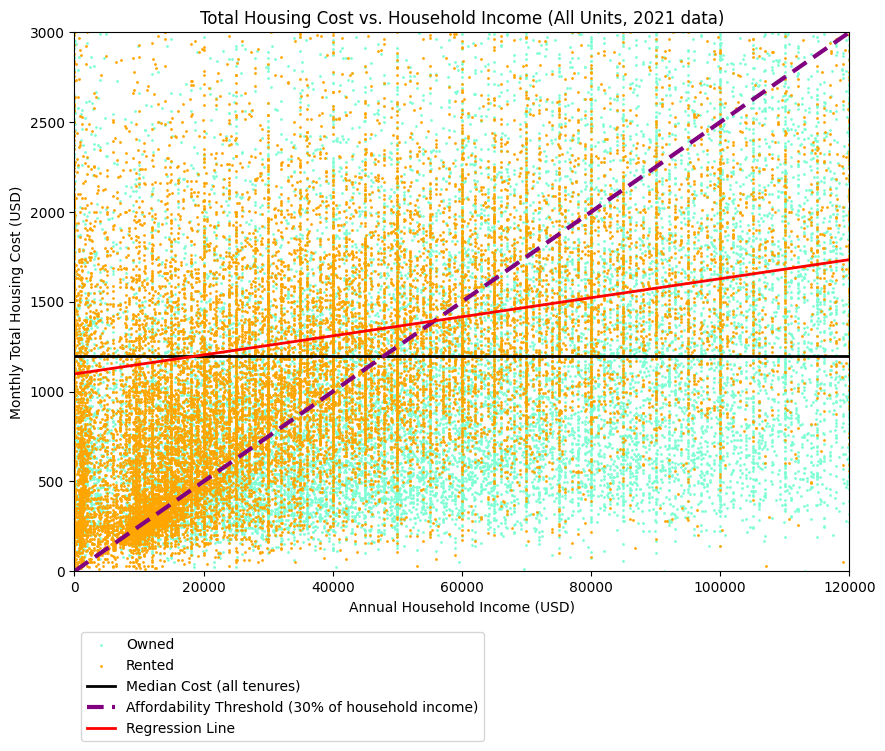

In [15]:
# Total Cost vs. Income Scatterplot, All Units

print(f'Regression intercept: {model.intercept_}')
print(f'Regression slope: {model.coef_[0]}')
print(f'Meta: {bp_all_no_log}')

fig, ax = plt.subplots(figsize=(10, 7))

ax.scatter(x=df_owned['HINCP'], y=df_owned['TOTHCAMT'], c='aquamarine', s=1, label='Owned')
ax.scatter(x=df_rented['HINCP'], y=df_rented['TOTHCAMT'], c='orange', s=1, label='Rented')
ax.axline(xy1=(0,median_all), slope=0, lw=2, color='black', label='Median Cost (all tenures)')
ax.axline(xy1=(0,0), slope=0.025, lw=3, dashes=(4,2), color='purple', label='Affordability Threshold (30% of household income)')
ax.axline(xy1=(0, model.intercept_), lw=2, slope=model.coef_[0], color='red', label='Regression Line')
plt.axis([0, 120000, 0, 3000])
plt.xlabel('Annual Household Income (USD)')
plt.ylabel('Monthly Total Housing Cost (USD)')
plt.title('Total Housing Cost vs. Household Income (All Units, 2021 data)')
_ = plt.legend(loc='upper left', bbox_to_anchor=(0, -0.1))

Regression intercept: 1093.2364679863547
Regression slope: 0.005295843887605199
Meta: {'med': np.int64(1200), 'q1': np.int64(665), 'q3': np.int64(1986), 'whislo': np.int64(0), 'whishi': np.int64(3967), 'fliers': 34944      3968
49469      3968
47079      3968
51893      3970
4212       3971
          ...  
12289     98229
51604    103154
37530    105264
37043    173782
10170    203093
Name: TOTHCAMT, Length: 1925, dtype: int64, 'label': 'Owned', 'mean': np.float64(1651.6352035298396)}


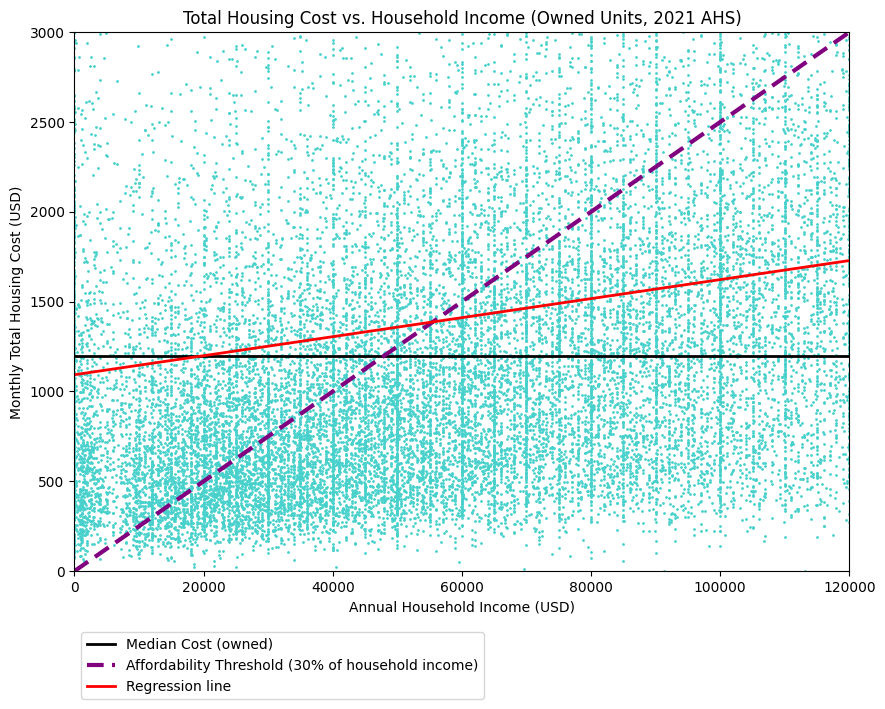

In [16]:
# Total Cost vs. Income Scatterplot, Owned Units

print(f'Regression intercept: {model_owned.intercept_}')
print(f'Regression slope: {model_owned.coef_[0]}')
print(f'Meta: {bp_owned_no_log}')

fig, ax = plt.subplots(figsize=(10, 7))

ax.scatter(x=df_owned['HINCP'], y=df_owned['TOTHCAMT'], c='mediumturquoise', s=1)
ax.axline(xy1=(0,median_owned), slope=0, lw=2, color='black', label='Median Cost (owned)')
plt.axline(xy1=(0,0), slope=0.025, lw=3, dashes=(4,2), color='purple', label='Affordability Threshold (30% of household income)')
plt.axline(xy1=(0, model_owned.intercept_), lw=2, slope=model_owned.coef_[0], color='red', label='Regression line')
plt.axis([0, 120000, 0, 3000])
plt.xlabel('Annual Household Income (USD)')
plt.ylabel('Monthly Total Housing Cost (USD)')
plt.title('Total Housing Cost vs. Household Income (Owned Units, 2021 AHS)')
_ = plt.legend(loc='upper left', bbox_to_anchor=(0, -0.1))

Regression intercept: 1101.0878595455265
Regression slope: 0.0054307079071602374
Meta: {'med': np.int64(1190), 'q1': np.int64(810), 'q3': np.int64(1710), 'whislo': np.int64(10), 'whishi': np.int64(3060), 'fliers': 1829     3061
37007    3063
59810    3064
16440    3066
398      3070
         ... 
27155    7322
43974    7390
39264    7490
9209     7599
44197    7730
Name: TOTHCAMT, Length: 1107, dtype: int64, 'label': 'Rented', 'mean': np.float64(1419.460754494405)}


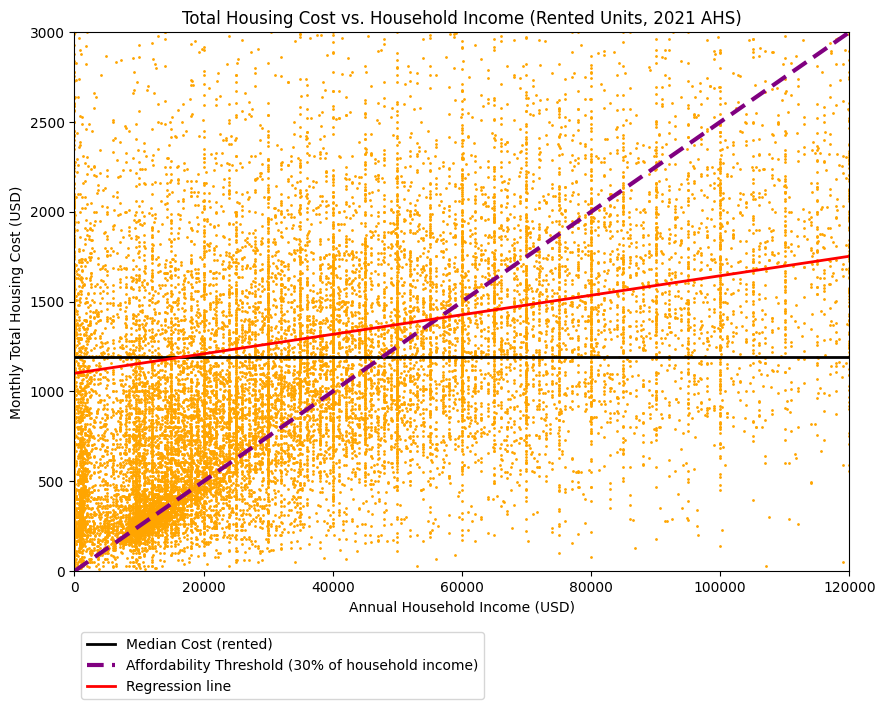

In [17]:
# Total Cost vs. Income Scatterplot, Rented Units

print(f'Regression intercept: {model_rented.intercept_}')
print(f'Regression slope: {model_rented.coef_[0]}')
print(f'Meta: {bp_rented_no_log}')

fig, ax = plt.subplots(figsize=(10, 7))

ax.scatter(x=df_rented['HINCP'], y=df_rented['TOTHCAMT'], c='orange', s=1)
ax.axline(xy1=(0,median_rented), slope=0, lw=2, color='black', label='Median Cost (rented)')
plt.axline(xy1=(0,0), slope=0.025, lw=3, dashes=(4,2), color='purple', label='Affordability Threshold (30% of household income)')
plt.axline(xy1=(0, model_rented.intercept_), lw=2, slope=model_rented.coef_[0], color='red', label='Regression line')
plt.axis([0, 120000, 0, 3000])
plt.xlabel('Annual Household Income (USD)')
plt.ylabel('Monthly Total Housing Cost (USD)')
plt.title('Total Housing Cost vs. Household Income (Rented Units, 2021 AHS)')
_ = plt.legend(loc='upper left', bbox_to_anchor=(0, -0.1))

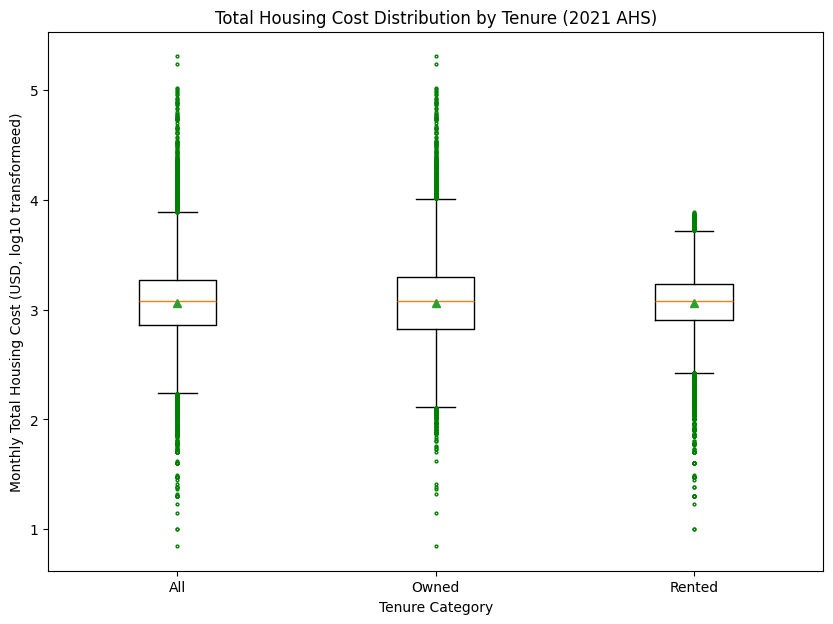

In [18]:
box_stats = [bp_all, bp_owned, bp_rented]
flierprops = {'markersize': 4, 'marker': '.', 'markeredgecolor': 'green'}

fig, ax = plt.subplots(figsize=(10,7))
ax.bxp(box_stats, showfliers=True, flierprops=flierprops, showmeans=True)
plt.xlabel('Tenure Category')
plt.ylabel('Monthly Total Housing Cost (USD, log10 transformeed)')
_ = plt.title('Total Housing Cost Distribution by Tenure (2021 AHS)')

In [19]:
def get_homecounts(cat):
    df, _ = cat
    sum_weight = df['WEIGHT'].sum()
    return sum_weight / 1000

In [20]:
# Select only single-family owner-occupied homes, for comparison with SOC data

sf_owned_2021 = ahs2021[ahs2021['TENURE'] == '1']
sf_owned_2021 = sf_owned_2021[sf_owned_2021['BLD'] == '02']

In [21]:
# Analysis by Square-Footage Category, Owned Single-Family Homes

df = sf_owned_2021[['WEIGHT', 'UNITSIZE', 'MARKETVAL']]
df = df[df['UNITSIZE'] != '-9']

s_less_500 = df[df['UNITSIZE'] == '1']
s_500_749 = df[df['UNITSIZE'] == '2']
s_750_999 = df[df['UNITSIZE'] == '3']
s_1000_1499 = df[df['UNITSIZE'] == '4']
s_1500_1999 = df[df['UNITSIZE'] == '5']
s_2000_2499 = df[df['UNITSIZE'] == '6']
s_2500_2999 = df[df['UNITSIZE'] == '7']
s_3000_3999 = df[df['UNITSIZE'] == '8']
s_4000_plus = df[df['UNITSIZE'] == '9']
    
cats = [(s_less_500, '< 500 sqft.'), (s_500_749, '500-749 sqft.'), (s_750_999, '750-999 sqft.'), (s_1000_1499, '1000-1499 sqft.'),
        (s_1500_1999, '1500-1999 sqft.'), (s_2000_2499, '2000-2499 sqft.'), (s_2500_2999, '2500-2999 sqft.'),
        (s_3000_3999, '3000-3999 sqft.'), (s_4000_plus, '4000+ sqft.')]

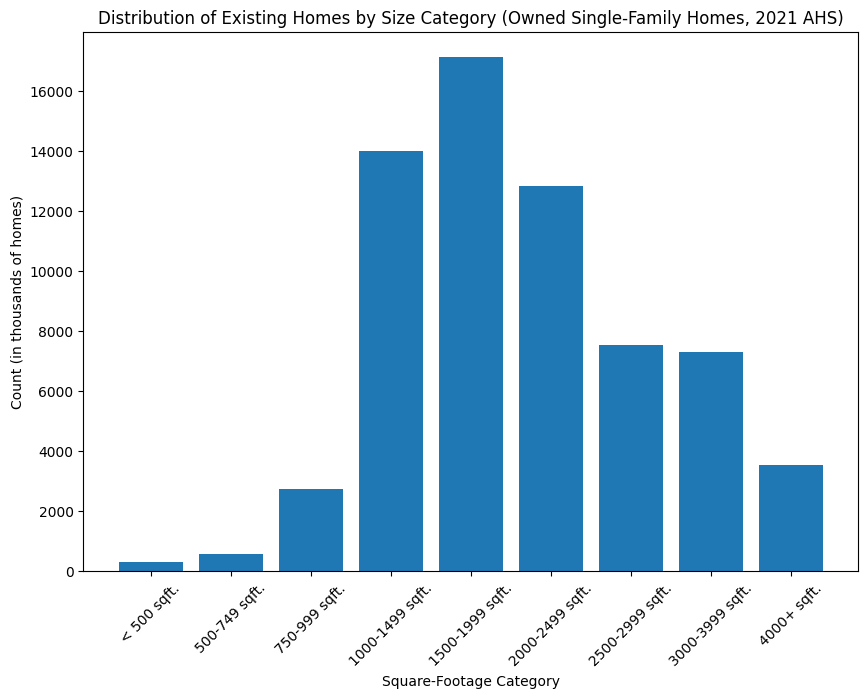

In [22]:
# Distribution by Square Footage Category

barlabels = [cat[1] for cat in cats]
barheights = [get_homecounts(cat) for cat in cats]
fig, ax = plt.subplots(figsize=(10,7))
ax.bar(barlabels, barheights)
plt.title('Distribution of Existing Homes by Size Category (Owned Single-Family Homes, 2021 AHS)')
plt.xticks(rotation=45)
plt.xlabel('Square-Footage Category')
_ = plt.ylabel('Count (in thousands of homes)')

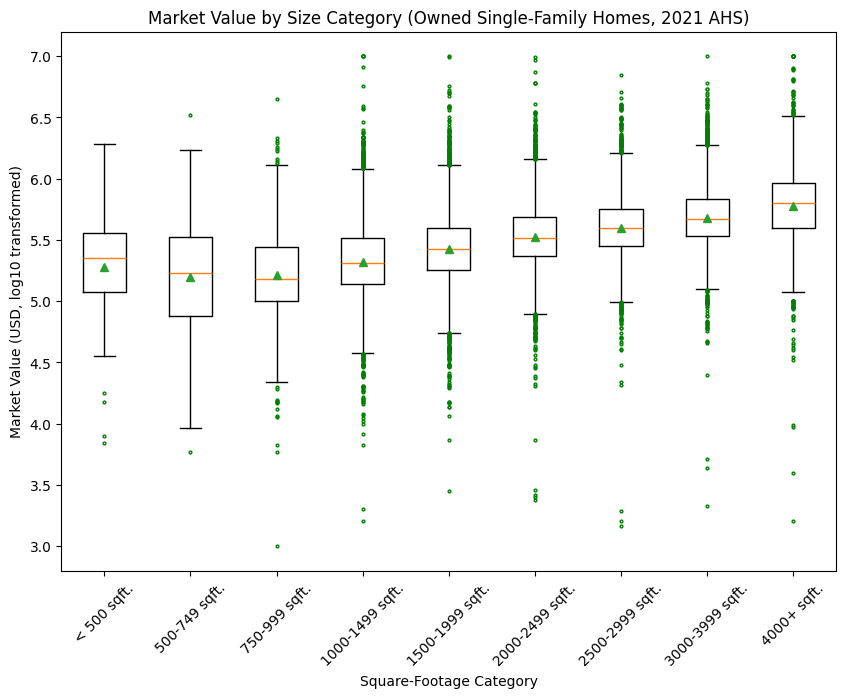

In [23]:
# Market Value by Square-Footage Category

box_stats = [get_bxpstats('MARKETVAL', cat, log=True) for cat in cats]

flierprops = {'markersize': 4, 'marker': '.', 'markeredgecolor': 'green'}

fig, ax = plt.subplots(figsize=(10,7))
ax.bxp(box_stats, showfliers=True, flierprops=flierprops, showmeans=True)
plt.title('Market Value by Size Category (Owned Single-Family Homes, 2021 AHS)')
plt.xlabel('Square-Footage Category')
plt.xticks(rotation=45)
_ = plt.ylabel('Market Value (USD, log10 transformed)')

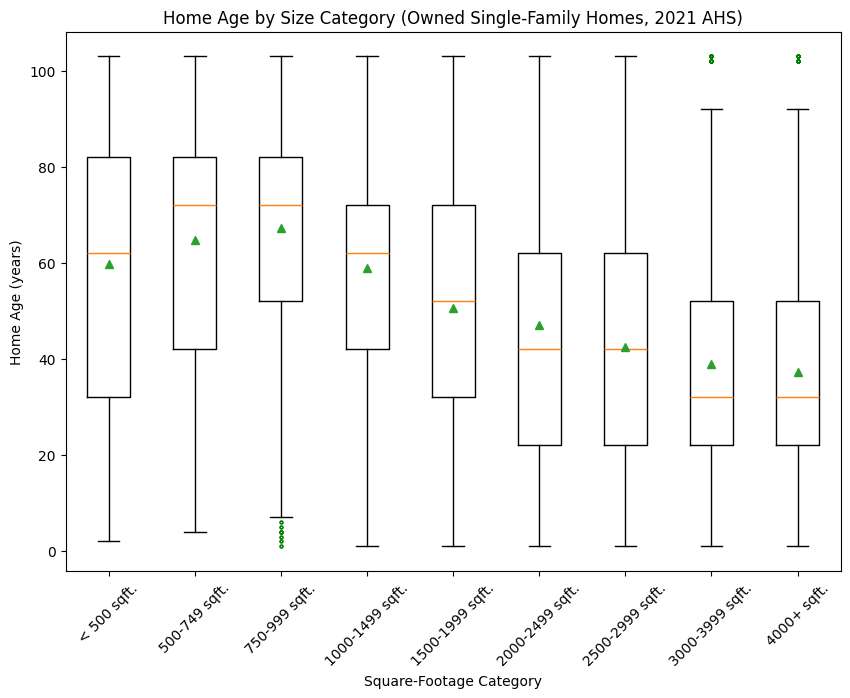

In [24]:
# Home Age vs. Square Footage, Owned Single-Family Homes

df = sf_owned_2021[['WEIGHT', 'UNITSIZE', 'YRBUILT']]
df = df[df['UNITSIZE'] != '-9']
df['AGE'] = 2022 - df['YRBUILT']

s_less_500 = df[df['UNITSIZE'] == '1']
s_500_749 = df[df['UNITSIZE'] == '2']
s_750_999 = df[df['UNITSIZE'] == '3']
s_1000_1499 = df[df['UNITSIZE'] == '4']
s_1500_1999 = df[df['UNITSIZE'] == '5']
s_2000_2499 = df[df['UNITSIZE'] == '6']
s_2500_2999 = df[df['UNITSIZE'] == '7']
s_3000_3999 = df[df['UNITSIZE'] == '8']
s_4000_plus = df[df['UNITSIZE'] == '9']

    
cats = [(s_less_500, '< 500 sqft.'), (s_500_749, '500-749 sqft.'), (s_750_999, '750-999 sqft.'), (s_1000_1499, '1000-1499 sqft.'),
        (s_1500_1999, '1500-1999 sqft.'), (s_2000_2499, '2000-2499 sqft.'), (s_2500_2999, '2500-2999 sqft.'),
        (s_3000_3999, '3000-3999 sqft.'), (s_4000_plus, '4000+ sqft.')]

box_stats = [get_bxpstats('AGE', cat, log=False) for cat in cats]

flierprops = {'markersize': 4, 'marker': '.', 'markeredgecolor': 'green'}

fig, ax = plt.subplots(figsize=(10,7))
ax.bxp(box_stats, showfliers=True, flierprops=flierprops, showmeans=True)
plt.title('Home Age by Size Category (Owned Single-Family Homes, 2021 AHS)')
plt.xlabel('Square-Footage Category')
plt.xticks(rotation=45)
_ = plt.ylabel('Home Age (years)')

In [25]:
# Analysis by Lot Size Category, Owned Single-Family Homes

df = sf_owned_2021[['WEIGHT', 'LOTSIZE', 'MARKETVAL']]
df = df[df['LOTSIZE'] != '-6']

l_less_1_8 = df[df['LOTSIZE'] == '1']
l_1_8_to_1_4 = df[df['LOTSIZE'] == '2']
l_1_4_to_1_2 = df[df['LOTSIZE'] == '3']
l_1_2_to_1 = df[df['LOTSIZE'] == '4']
l_1_to_5 = df[df['LOTSIZE'] == '5']
l_5_to_10 = df[df['LOTSIZE'] == '6']
l_10_plus = df[df['LOTSIZE'] == '7']
    
cats = [(l_less_1_8, '< 1/8 acre'), (l_1_8_to_1_4, '1/8 up to 1/4 acre'), (l_1_4_to_1_2, '1/4 up to 1/2 acre'),
        (l_1_2_to_1, '1/2 up to 1 acre'), (l_1_to_5, '1 up to 5 acres'), (l_5_to_10, '5 up to 10 acres'),
        (l_10_plus, '> 10 acres')]

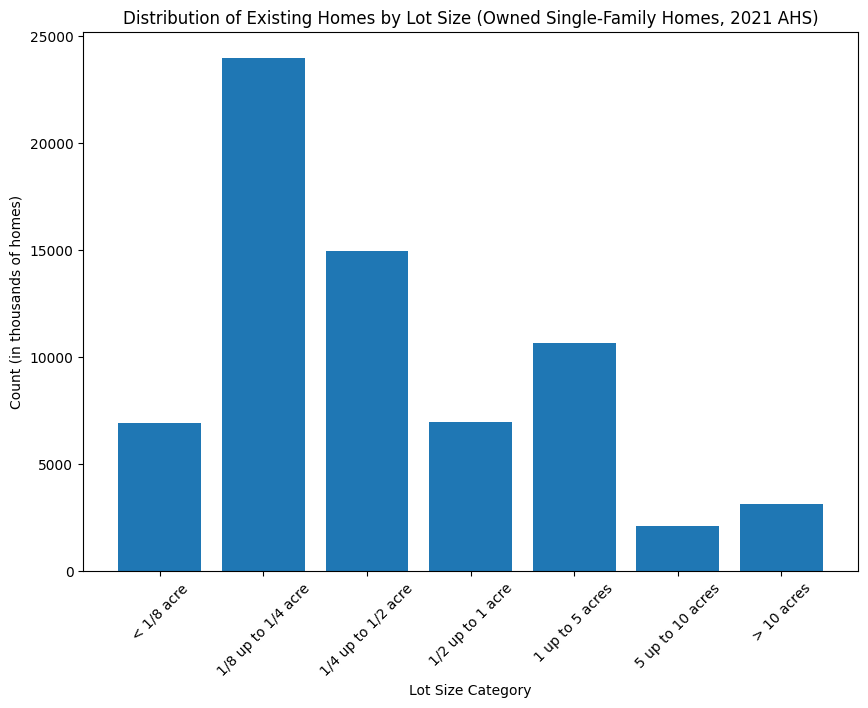

In [26]:
# Distribution by Lot Acreage

barlabels = [cat[1] for cat in cats]
barheights = [get_homecounts(cat) for cat in cats]
fig, ax = plt.subplots(figsize=(10,7))
ax.bar(barlabels, barheights)
plt.title('Distribution of Existing Homes by Lot Size (Owned Single-Family Homes, 2021 AHS)')
plt.xticks(rotation=45)
plt.xlabel('Lot Size Category')
_ = plt.ylabel('Count (in thousands of homes)')

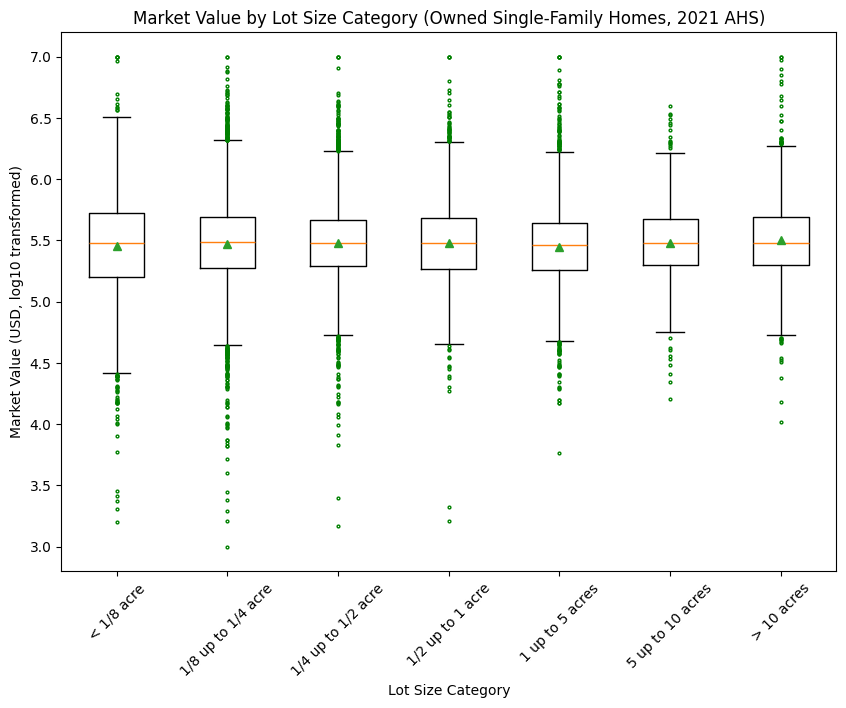

In [27]:
# Market Value by Lot Acreage

box_stats = [get_bxpstats('MARKETVAL', cat, log=True) for cat in cats]

flierprops = {'markersize': 4, 'marker': '.', 'markeredgecolor': 'green'}

fig, ax = plt.subplots(figsize=(10,7))
ax.bxp(box_stats, showfliers=True, flierprops=flierprops, showmeans=True)
plt.title('Market Value by Lot Size Category (Owned Single-Family Homes, 2021 AHS)')
plt.xlabel('Lot Size Category')
plt.xticks(rotation=45)
_ = plt.ylabel('Market Value (USD, log10 transformed)')

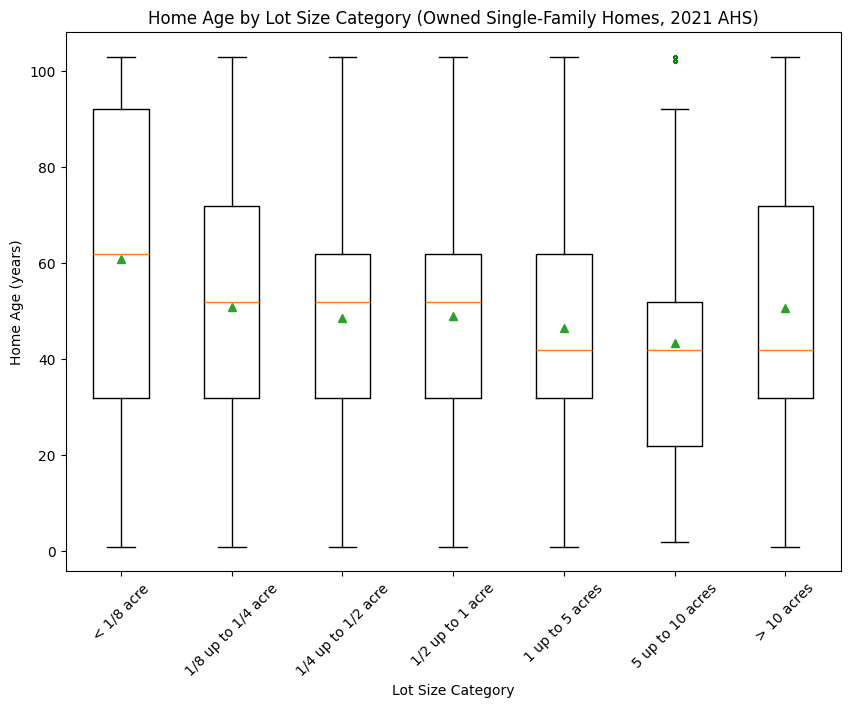

In [28]:
# Home Age vs. Square Footage, Owned Single-Family Homes

df = sf_owned_2021[['WEIGHT', 'LOTSIZE', 'YRBUILT']]
df = df[df['LOTSIZE'] != '-6']
df['AGE'] = 2022 - df['YRBUILT']

l_less_1_8 = df[df['LOTSIZE'] == '1']
l_1_8_to_1_4 = df[df['LOTSIZE'] == '2']
l_1_4_to_1_2 = df[df['LOTSIZE'] == '3']
l_1_2_to_1 = df[df['LOTSIZE'] == '4']
l_1_to_5 = df[df['LOTSIZE'] == '5']
l_5_to_10 = df[df['LOTSIZE'] == '6']
l_10_plus = df[df['LOTSIZE'] == '7']
    
cats = [(l_less_1_8, '< 1/8 acre'), (l_1_8_to_1_4, '1/8 up to 1/4 acre'), (l_1_4_to_1_2, '1/4 up to 1/2 acre'),
        (l_1_2_to_1, '1/2 up to 1 acre'), (l_1_to_5, '1 up to 5 acres'), (l_5_to_10, '5 up to 10 acres'),
        (l_10_plus, '> 10 acres')]

box_stats = [get_bxpstats('AGE', cat, log=False) for cat in cats]

flierprops = {'markersize': 4, 'marker': '.', 'markeredgecolor': 'green'}

fig, ax = plt.subplots(figsize=(10,7))
ax.bxp(box_stats, showfliers=True, flierprops=flierprops, showmeans=True)
plt.title('Home Age by Lot Size Category (Owned Single-Family Homes, 2021 AHS)')
plt.xlabel('Lot Size Category')
plt.xticks(rotation=45)
_ = plt.ylabel('Home Age (years)')

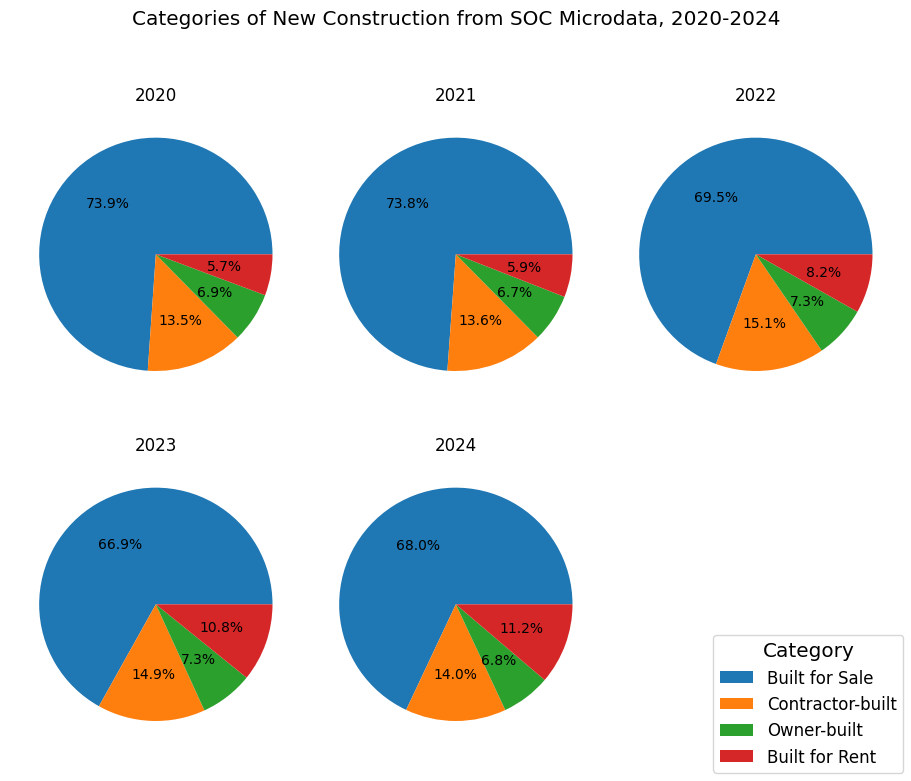

In [29]:
# Category of New Construction, 5 years (SOC)

fig, axs = plt.subplots(ncols=3, nrows=2, figsize=(9, 7), layout='constrained')
labels = ['Built for Sale', 'Contractor-built', 'Owner-built', 'Built for Rent']
fig.suptitle('Categories of New Construction from SOC Microdata, 2020-2024',
             fontsize='x-large',
             y=1.1
            )

wedges = None

for (i, tp) in enumerate(soc_years):
    row = i // 3
    col = i % 3
    (year, df) = tp

    df = df[['WEIGHT', 'CAT']]
    totals = df.groupby(['CAT']).sum()

    ax = axs[row, col]
    wedges, _, _ = ax.pie(totals['WEIGHT'], labels=labels, labeldistance=None, autopct='%1.1f%%')
    ax.set_title(year)

axs[1, 2].set_visible(False)
_ = fig.legend(wedges, labels, loc='lower right', fontsize='large', title_fontsize='x-large', title='Category')

In [30]:
# New Construction distribution by Squre Footage 

df = soc_all[['WEIGHT', 'SQFS']]
df = df[df['SQFS'] > 0]

s_less_500 = df[df['SQFS'] < 500]
s_500_749 = df[(df['SQFS'] >= 500) & (df['SQFS'] < 750)]
s_750_999 = df[(df['SQFS'] >= 750) & (df['SQFS'] < 1000)]
s_1000_1499 = df[(df['SQFS'] >= 1000) & (df['SQFS'] < 1500)]
s_1500_1999 = df[(df['SQFS'] >= 1500) & (df['SQFS'] < 2000)]
s_2000_2499 = df[(df['SQFS'] >= 2000) & (df['SQFS'] < 2500)]
s_2500_2999 = df[(df['SQFS'] >= 2500) & (df['SQFS'] < 3000)]
s_3000_3999 = df[(df['SQFS'] >= 3000) & (df['SQFS'] < 4000)]
s_4000_plus = df[df['SQFS'] >= 4000]

cats = [(s_less_500, '< 500 sqft.'), (s_500_749, '500-749 sqft.'), (s_750_999, '750-999 sqft.'), (s_1000_1499, '1000-1499 sqft.'),
        (s_1500_1999, '1500-1999 sqft.'), (s_2000_2499, '2000-2499 sqft.'), (s_2500_2999, '2500-2999 sqft.'),
        (s_3000_3999, '3000-3999 sqft.'), (s_4000_plus, '4000+ sqft.')]

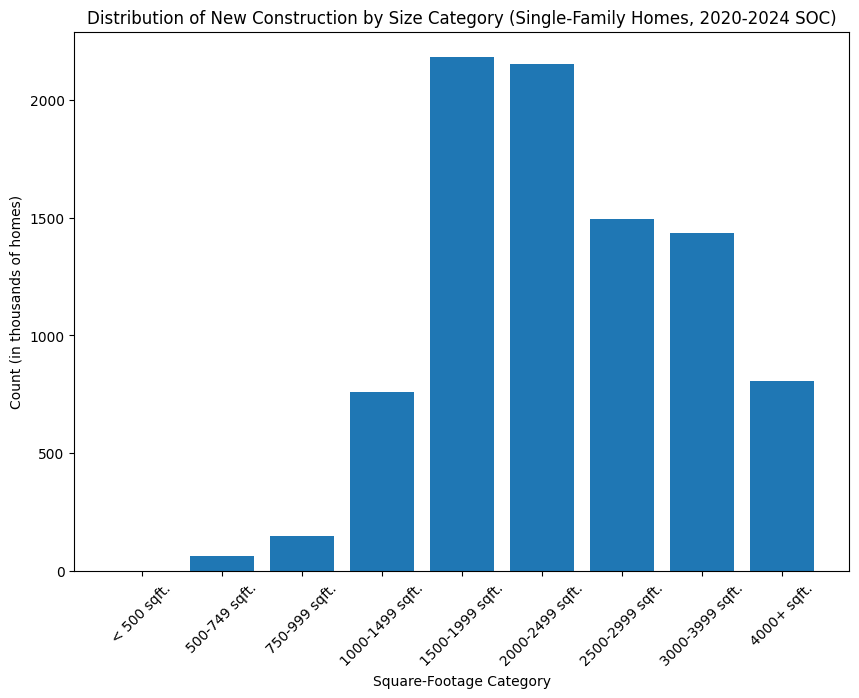

In [31]:
# Distribution by Square Footage Category (Bar Chart)

barlabels = [cat[1] for cat in cats]
barheights = [get_homecounts(cat) for cat in cats]
fig, ax = plt.subplots(figsize=(10,7))
ax.bar(barlabels, barheights)
plt.title('Distribution of New Construction by Size Category (Single-Family Homes, 2020-2024 SOC)')
plt.xticks(rotation=45)
plt.xlabel('Square-Footage Category')
_ = plt.ylabel('Count (in thousands of homes)')

In [32]:
soc_all['AREA'].value_counts()

AREA
0         32855
8700       7936
13100      4814
4400       3557
43600      3400
          ...  
56400         1
49300         1
406600        1
99500         1
246100        1
Name: count, Length: 986, dtype: int64

In [33]:
df = soc_all[soc_all['AREA'] != 0][['WEIGHT', 'AREA']]
df['ACRES'] = df['AREA'] / 43560

l_less_1_8 = df[df['ACRES'] < 0.125]
l_1_8_to_1_4 = df[(df['ACRES'] >= 0.125) & (df['ACRES'] < 0.25)]
l_1_4_to_1_2 = df[(df['ACRES'] >= 0.25) & (df['ACRES'] < 0.5)]
l_1_2_to_1 = df[(df['ACRES'] >= 0.5) & (df['ACRES'] < 1.0)]
l_1_to_5 = df[(df['ACRES'] >= 1.0) & (df['ACRES'] < 5.0)]
l_5_to_10 = df[(df['ACRES'] >= 5.0) & (df['ACRES'] < 10.0)]
l_10_plus = df[df['ACRES'] >= 10.0]

cats = [(l_less_1_8, '< 1/8 acre'), (l_1_8_to_1_4, '1/8 up to 1/4 acre'), (l_1_4_to_1_2, '1/4 up to 1/2 acre'),
        (l_1_2_to_1, '1/2 up to 1 acre'), (l_1_to_5, '1 up to 5 acres'), (l_5_to_10, '5 up to 10 acres'),
        (l_10_plus, '> 10 acres')]

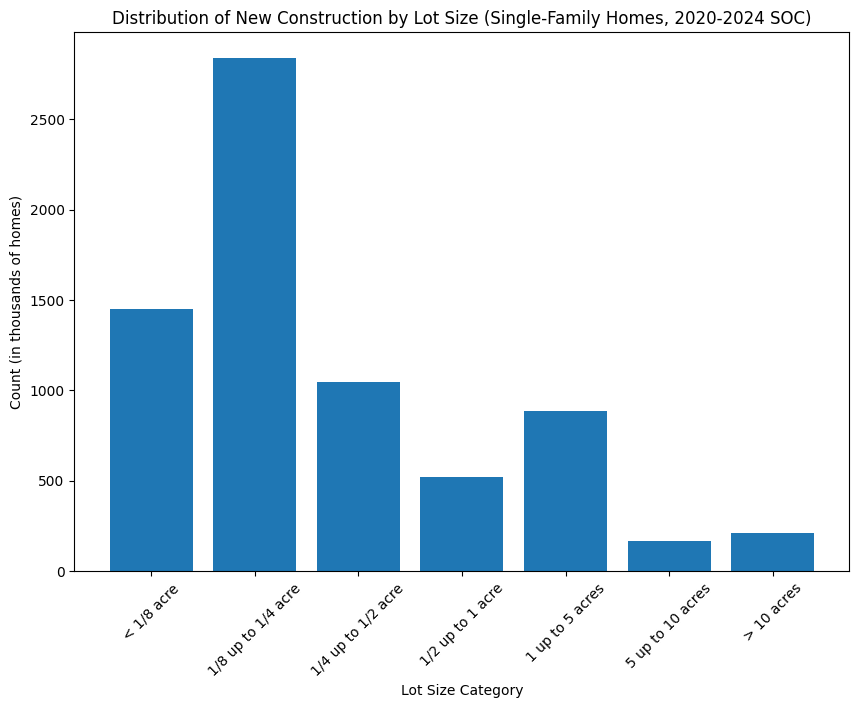

In [34]:
# Distribution of New Construction by Lot Acreage

barlabels = [cat[1] for cat in cats]
barheights = [get_homecounts(cat) for cat in cats]
fig, ax = plt.subplots(figsize=(10,7))
ax.bar(barlabels, barheights)
plt.title('Distribution of New Construction by Lot Size (Single-Family Homes, 2020-2024 SOC)')
plt.xticks(rotation=45)
plt.xlabel('Lot Size Category')
_ = plt.ylabel('Count (in thousands of homes)')